# Student Perception Output Analysis

This notebook presents a brief analysis of the results discussed in this research paper. The notebook is structured as follows:

1. **Initial setup:** Necessary initial configurations, such as customizing dataframes to display the full content of rows and columns, styling the presented tables, and providing functions to convert PDF figures to PNG format to enable their display in this Jupyter Notebook.
2. **Defining the $k$ topics number:** Presentation of the $C_v$ coherence and topic diversity (IRBO) charts to determine the optimal number of topics for each model.
3. **Topic modeling:** Presentation of all topics generated by each of the modeling algorithms.
4. **Qualitative comparative inter-model analysis:** 
  * **Common topics:** Presentation of the common topics across models, found using a similarity graph and community detection with the Louvain algorithm.
  * **Exclusive topics:** Presentation of the exclusive topics detected by a single model, also found using a similarity graph and community detection with the Louvain algorithm.
5. **Automatic generative topic labeling:** Presentation of the automatic labels generated by the Llama LLM for the topics produced by the BERTopic algorithm.

> **Disclaimer regarding language:** It is important to highlight that the original dataset and all raw results—including both the topic modeling outputs and the automatic generative labeling—were originally processed and obtained in Portuguese. However, to align with the language requirements of this research paper and facilitate the comprehension, the results presented in this notebook have been translated into English.

## Initial setup

### Dependencies and Environment Configuration
In this section, we import the necessary libraries and configure the display settings for Pandas DataFrames. This ensures that the qualitative and quantitative analysis tables are rendered correctly and comprehensively, preventing text truncation during the notebook presentation.

In [1]:
from pdf2image import convert_from_path
import os
from IPython.display import Image, display
import pandas as pd

In [2]:
# Show all rows
pd.set_option('display.max_rows', None)

# Show all cols
pd.set_option('display.max_columns', None)

# Show full content of each cell
pd.set_option('display.max_colwidth', None)

# Tables style
table_style = {
    'text-align': 'left',
    'border': '1px solid grey',
    'font-family': 'Arial',
    
}

### PDF to PNG Conversion Utility
Since the analytical plots generated during this research were originally exported in PDF format for high-resolution publication purposes, we define a helper function to convert these files into PNG format. This approach allows us to display the charts inline within the Jupyter environment without losing quality.

In [3]:
def convert_pdf_to_png(pdf_path, output_folder):
    # Convert the PDF into a list of images
    img = convert_from_path(pdf_path)
    
    # Get the file name without the '.pdf' extension
    base_name = os.path.splitext(os.path.basename(pdf_path))[0]
    
    for i, image in enumerate(img):
        # Define the output file name
        png_path = os.path.join(output_folder, f"{base_name}.png")
        # Save the image as a PNG file
        image.save(png_path, "PNG")
        print(f"Saved: {png_path}")

In [4]:
figures_path = "../output/figure/"

In [5]:
coherence_pdf = os.path.join(figures_path, "coherence_plot.pdf")
convert_pdf_to_png(coherence_pdf, figures_path)

Saved: ../output/figure/coherence_plot.png


In [6]:
irbo_pdf = os.path.join(figures_path, "irbo_plot.pdf")
convert_pdf_to_png(irbo_pdf, figures_path)

Saved: ../output/figure/irbo_plot.png


In [7]:
supertopics_pdf = os.path.join(figures_path, "super_topics.pdf")
convert_pdf_to_png(supertopics_pdf, figures_path)

Saved: ../output/figure/super_topics.png


## Topic Granularity ($k$) Definition
In topic modeling, determining the ideal number of topics ($k$) is a critical step to achieve a balance between model interpretability and topic diversity. In this section, we evaluate the performance of our models across different values of $k$ using two metrics: Topic Coherence ($C_v$) and Inverted Rank-Biased Overlap (IRBO).


### Coherence ($C_v$)
The $C_v$ coherence score measures the semantic similarity between the top words within each topic. A higher coherence indicates that the generated topics are more meaningful and human-interpretable. The chart below illustrates the coherence scores across different values of $k$ for the evaluated models.


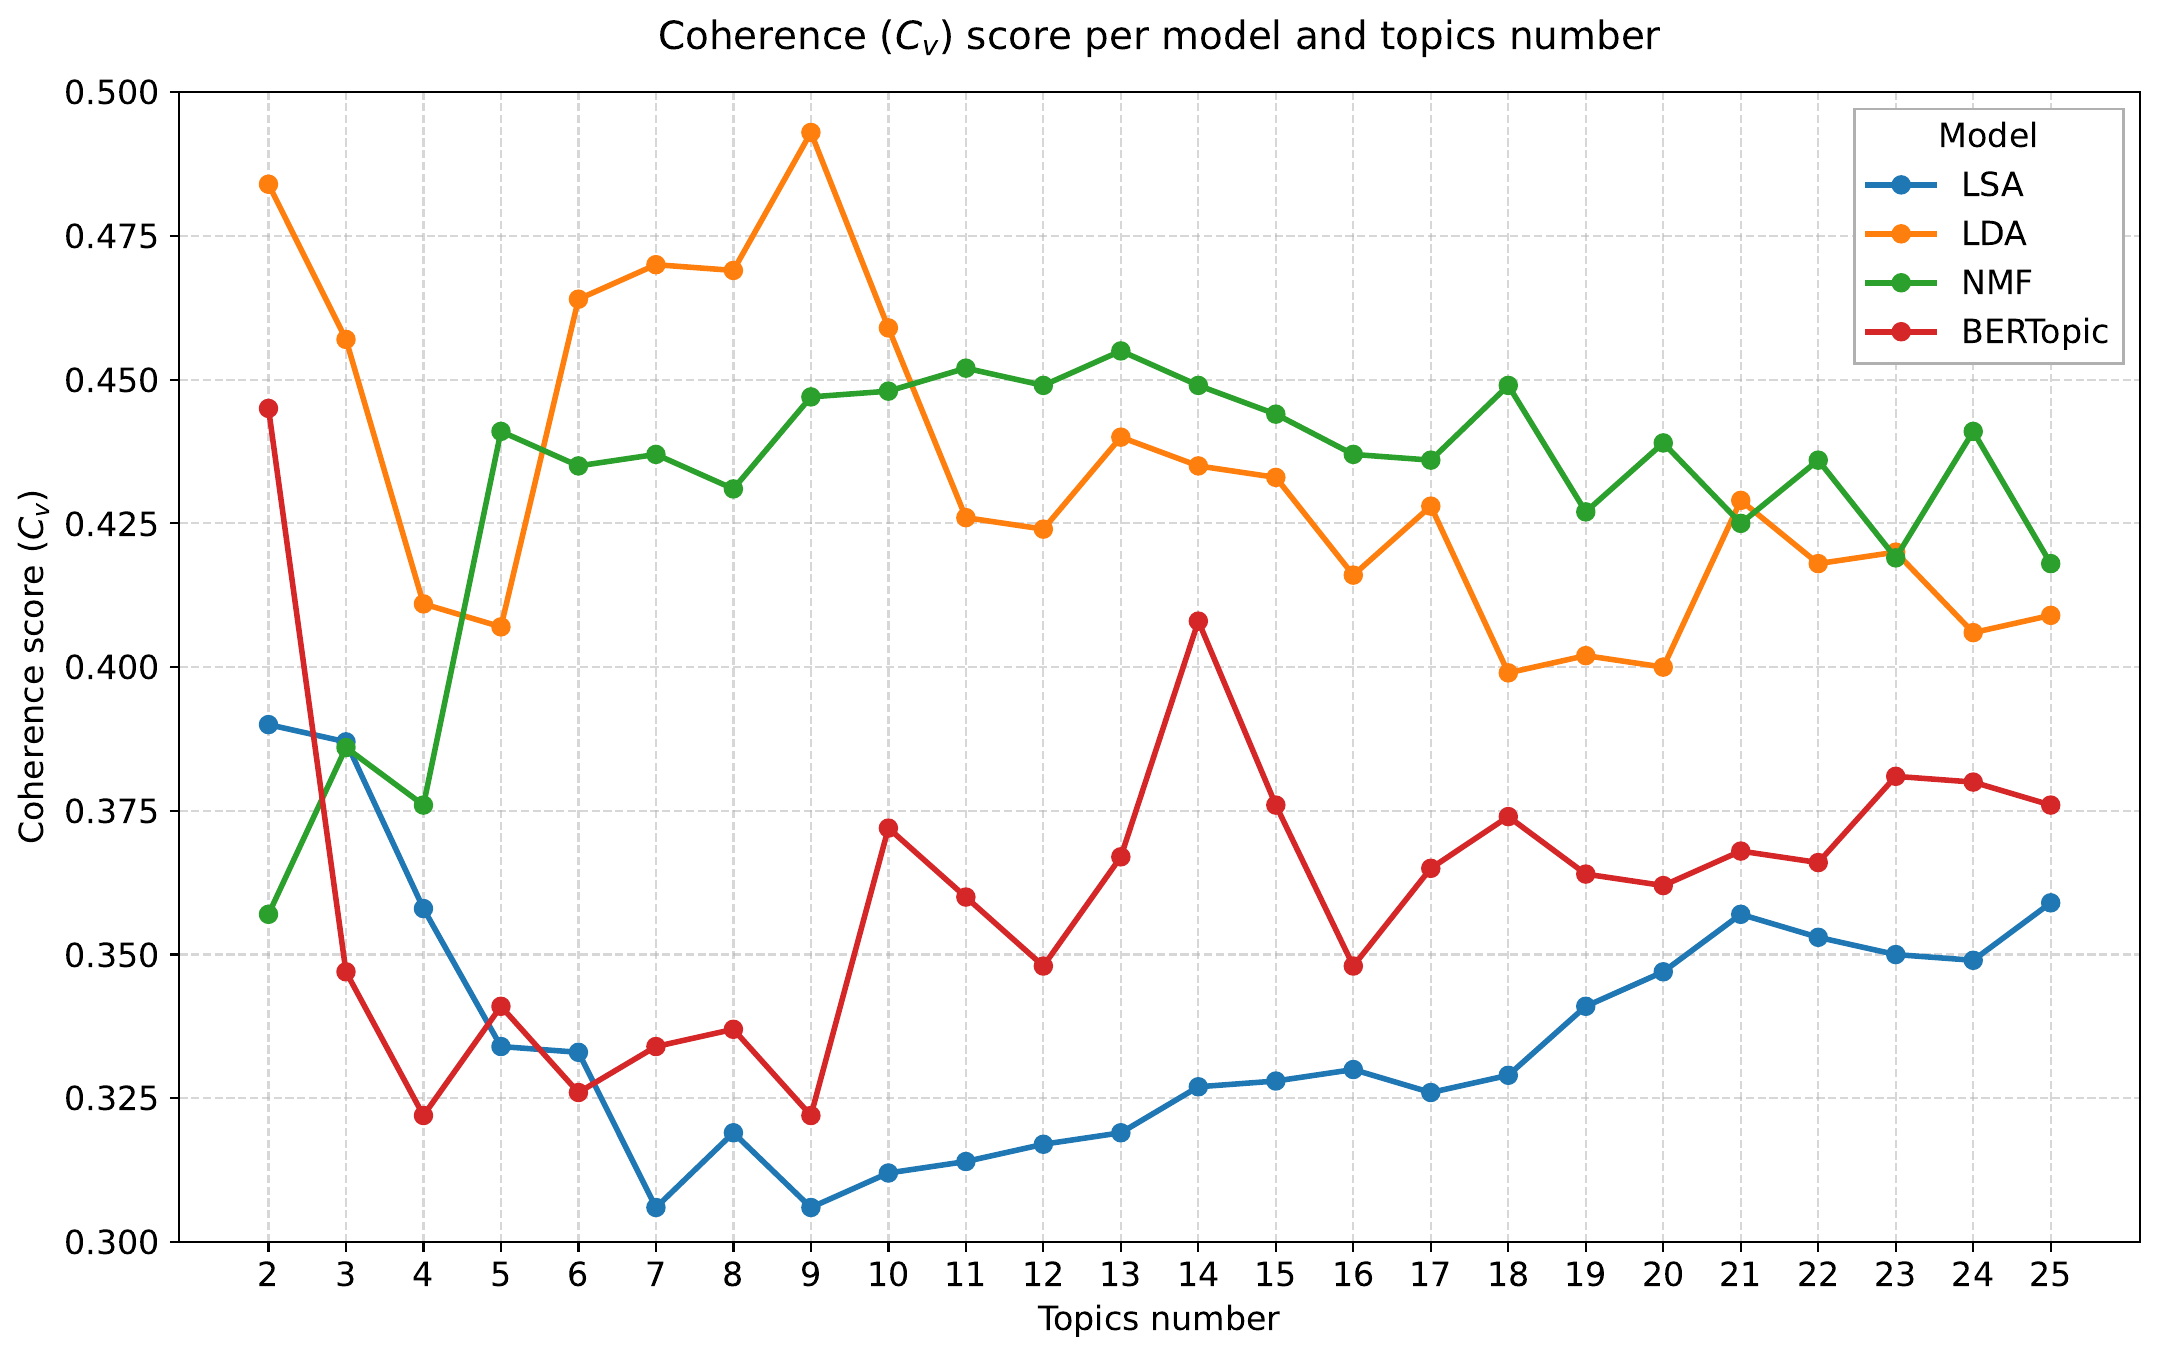

In [8]:
display(Image(filename='../output/figure/coherence_plot.png'))

### Topic Diversity (IRBO)
While coherence is essential, ensuring that the generated topics are distinct from one another is equally crucial to prevent thematic redundancy. The Inverted Rank-Biased Overlap (IRBO) metric quantifies topic diversity by measuring the overlap between the top words of different topics. Higher diversity values suggest that the model successfully captures distinct themes. The following plot details the IRBO scores for each model.


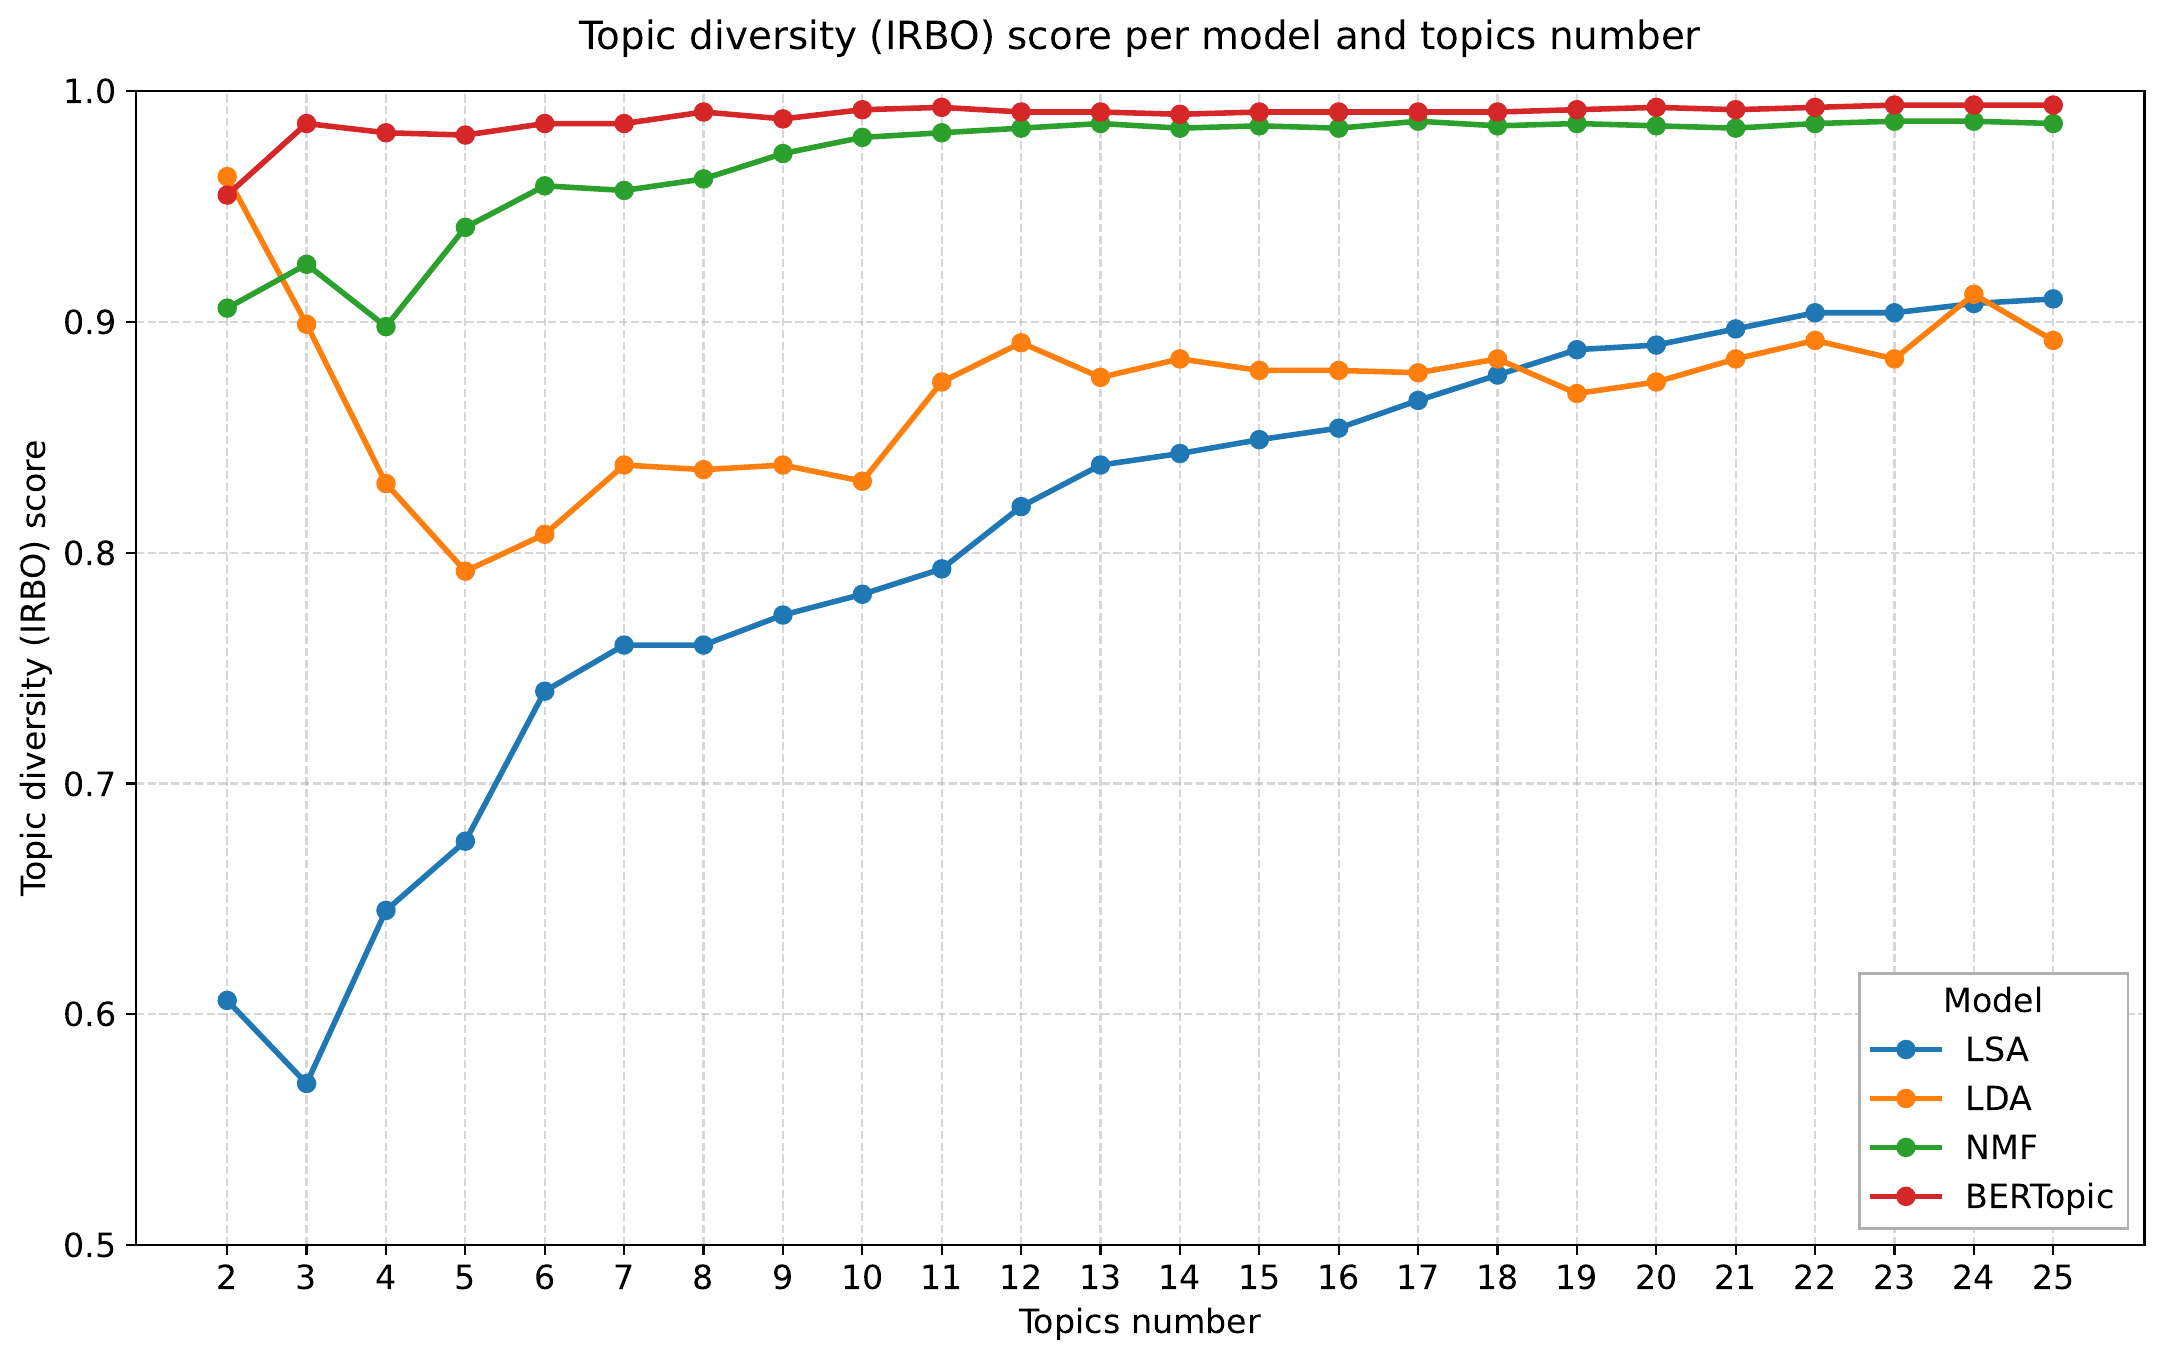

In [9]:
display(Image(filename='../output/figure/irbo_plot.png'))

As discussed in the paper, based on the models' stability in the IRBO metric from $k=13$ onwards, and within our defined analytical window of interest ($13 \leq k \leq 25$), the chosen number of topics ($k$) for each model was:

* **LSA:** $k=25$
* **LDA and NMF:** $k=13$
* **BERTopic:** $k=14$

## Topic Modeling

Having established the number of topics ($k$) for each algorithm, this section presents the actual topic representations discovered by the LSA, LDA, NMF, and BERTopic models. For each algorithm, we display a structured table containing the resulting topics alongside their most representative keywords. These sets of keywords encapsulate the core semantic themes identified within the student perceptions dataset, serving as the basis for our subsequent qualitative analysis.

In [10]:
all_models_topics_en = pd.read_csv('../output/topic_modeling/all_models_topics_en.csv')

### LSA

In [11]:
lsa_table = all_models_topics_en[all_models_topics_en['model'] == 'lsa'][['keywords']]
lsa_table

,keywords
0,"['good', 'excellent', 'teaching', 'great', 'teacher', 'well', 'subject', 'class', 'didactic', 'content', 'domain', 'explain', 'teach', 'discipline', 'always']"
1,"['excellent', 'well', 'teaching', 'explain', 'subject', 'teach', 'content', 'great', 'discipline', 'good', 'pass', 'exam', 'know', 'class', 'miss']"
2,"['good', 'excellent', 'great', 'domain', 'teaching', 'subject', 'well', 'minister', 'content', 'way', 'pass', 'about', 'attentive', 'clear', 'discipline']"
3,"['great', 'good', 'well', 'teacher', 'class', 'explain', 'semester', 'dynamic', 'content', 'excellent', 'can', 'professional', 'attentive', 'do', 'interact']"
4,"['well', 'explain', 'subject', 'great', 'good', 'teacher', 'teach', 'domain', 'didactic', 'class', 'little', 'miss', 'improve', 'semester', 'exam']"
5,"['attentive', 'didactic', 'teacher', 'always', 'teaching', 'great', 'improve', 'helpful', 'help', 'need', 'explain', 'good', 'dedicate', 'doubt', 'domain']"
6,"['didactic', 'attentive', 'teaching', 'improve', 'domain', 'well', 'helpful', 'great', 'explain', 'always', 'need', 'teacher', 'help', 'subject', 'knowledge']"
7,"['domain', 'well', 'didactic', 'explain', 'subject', 'excellent', 'improve', 'attentive', 'teaching', 'content', 'class', 'enough', 'exam', 'minister', 'clear']"
8,"['teaching', 'teacher', 'domain', 'class', 'always', 'good', 'clear', 'didactic', 'improve', 'objective', 'minister', 'teach', 'need', 'help', 'about']"
9,"['teacher', 'attentive', 'teach', 'domain', 'improve', 'great', 'dedicate', 'professional', 'teaching', 'class', 'always', 'help', 'dynamic', 'wonderful', 'miss']"


### LDA

In [12]:
lda_table = all_models_topics_en[all_models_topics_en['model'] == 'lda'][['keywords']].reset_index(drop=True)
lda_table

,keywords
0,"['discipline', 'teacher', 'little', 'beyond', 'explain', 'well', 'time', 'subject', 'class', 'comment', 'study', 'during', 'class', 'schedule', 'minister']"
1,"['class', 'leave', 'semester', 'trabalho', 'minister', 'discipline', 'some', 'subject', 'room', 'content', 'can', 'give', 'class', 'do', 'knowledge']"
2,"['do', 'class', 'that', 'dynamic', 'know', 'attentive', 'great', 'always', 'subject_matter', 'schedule', 'need', 'help', 'content', 'teaching', 'give']"
3,"['class', 'semester', 'discipline', 'teacher', 'good', 'content', 'give', 'evaluative', 'have', 'learn', 'beyond', 'hour', 'all', 'professional', 'harm']"
4,"['class', 'evaluation', 'class', 'miss', 'all', 'subject_matter', 'discipline', 'point', 'some', 'teaching', 'semester', 'course', 'need', 'only', 'exam']"
5,"['exam', 'little', 'class', 'manage', 'miss', 'know', 'charge', 'student', 'room', 'be', 'have', 'for', 'content', 'people', 'pass']"
6,"['exam', 'class', 'pass', 'explain', 'content', 'trabalho', 'well', 'semester', 'beyond', 'do', 'discipline', 'evaluation', 'criterion', 'just', 'other']"
7,"['subject', 'do', 'always', 'well', 'explain', 'class', 'subject_matter', 'great', 'interest', 'are', 'speak', 'take', 'time', 'teach', 'teaching']"
8,"['subject', 'way', 'class', 'teach', 'subject_matter', 'because', 'can', 'do', 'student', 'way', 'some', 'clear', 'discipline', 'only', 'evaluation']"
9,"['discipline', 'class', 'well', 'all', 'only', 'do', 'good', 'course', 'can', 'content', 'activity', 'know', 'use', 'are', 'pass']"


### NMF

In [13]:
nmf_table = all_models_topics_en[all_models_topics_en['model'] == 'nmf'][['keywords']].reset_index(drop=True)
nmf_table

,keywords
0,"['class', 'pass', 'exam', 'content', 'do', 'discipline', 'trabalho', 'evaluation', 'semester', 'little', 'leave', 'way', 'can', 'manage', 'have']"
1,"['excellent', 'professional', 'teacher', 'class', 'study', 'organize', 'feel', 'challenges', 'possess', 'didactic', 'prepare', 'point', 'general', 'congratulations', 'highly']"
2,"['good', 'class', 'semester', 'already', 'people', 'can', 'pass_on', 'mathematical', 'standard', 'make_effort', 'love', 'super', 'great', 'subject_matter', 'do']"
3,"['great', 'dynamic', 'professional', 'dedicate', 'teach', 'attention', 'charisma', 'semester', 'learn', 'perfect', 'teaching', 'partner', 'disposes', 'professional', 'success']"
4,"['well', 'explain', 'teach', 'subject', 'interact', 'educate', 'know', 'master', 'know', 'with', 'teach', 'reasoning', 'wonderful', 'enough', 'efficient']"
5,"['attentive', 'helpful', 'dedicate', 'disposition', 'interested', 'repeat', 'assiduous', 'understand', 'disciplinary', 'super', 'meticulous', 'willing', 'learning', 'technical', 'demands']"
6,"['didactic', 'improve', 'need', 'lack', 'leave', 'resource', 'extremely', 'organize', 'dialogue', 'tics', 'use', 'clear', 'highly', 'example', 'little']"
7,"['domain', 'subject', 'content', 'about', 'enough', 'subject_matter', 'discipline', 'minister', 'portuguese', 'contextualize', 'teach', 'treat', 'way', 'clear', 'high']"
8,"['teaching', 'bad', 'weak', 'possess', 'attention', 'objective', 'rushed', 'incredible', 'point', 'objective', 'congratulations', 'approach', 'terrible', 'patience', 'approach']"
9,"['teacher', 'wonderful', 'will', 'appropriate', 'very', 'learn', 'very_great', 'feel', 'notice', 'make_effort', 'enough', 'update', 'good', 'improve', 'teach']"


### BERTopic

In [14]:
bertopic_table = all_models_topics_en[all_models_topics_en['model'] == 'bertopic'][['keywords']].reset_index(drop=True)
bertopic_table

,keywords
0,"['excellent', 'always', 'great', 'well', 'good', 'didactics', 'great', 'good', 'doubts', 'subject', 'explains', 'content', 'about', 'super', 'objective']"
1,"['content', 'exam', 'room', 'evaluation', 'beyond', 'exams', 'passed', 'teaching', 'lack', 'little', 'just', 'works', 'didactics', 'time', 'times']"
2,"['schedule', 'times', 'reasons', 'some', 'time', 'many', 'too_much', 'was_missing', 'fast', 'bus', 'night', 'trabalho', 'many', 'punctual', 'are']"
3,"['domain', 'subject', 'content', 'enough', 'dia', 'about', 'well', 'passes', 'knowledge', 'taught', 'area', 'subjects', 'new', 'contextualized', 'otimas']"
4,"['didactics', 'little', 'excellent', 'intransigent', 'pretends', 'didactic', 'disorganized', 'terrible', 'points', 'extremely', 'knows', 'enough', 'unreal', 'right', 'explosive']"
5,"['disciplines', 'some', 'good', 'difficulties', 'despite', 'strike', 'fruitful', 'honestly', 'great', 'subjects', 'pass_on', 'after', 'time', 'general', 'unfortunately']"
6,"['evaluation', 'evaluations', 'could', 'correction', 'clear', 'corrected', 'included', 'discursive', 'method', 'confusing', 'just', 'left', 'in', 'exams', 'forms']"
7,"['always', 'attentive', 'willing', 'requests', 'humble', 'hardworking', 'congratulations', 'helpful', 'help', 'well', 'understood', 'engaged', 'disciplined', 'highly', 'arbitrary']"
8,"['nothing', 'joined', 'appears', 'declare', 'arrives', 'nor', 'occurred', 'early', 'error', 'social', 'name', 'moment', 'evaluate', 'did', 'grade']"
9,"['professional', 'ok', 'impeccable', 'qualified', 'fun', 'xxxxxxxxxxxx', 'regular', 'wonderful', 'wonderful', 'present', 'objective', 'name', 'sir', 'good', 'horrible']"


## Qualitative comparative analysis inter-model

### Common Topics

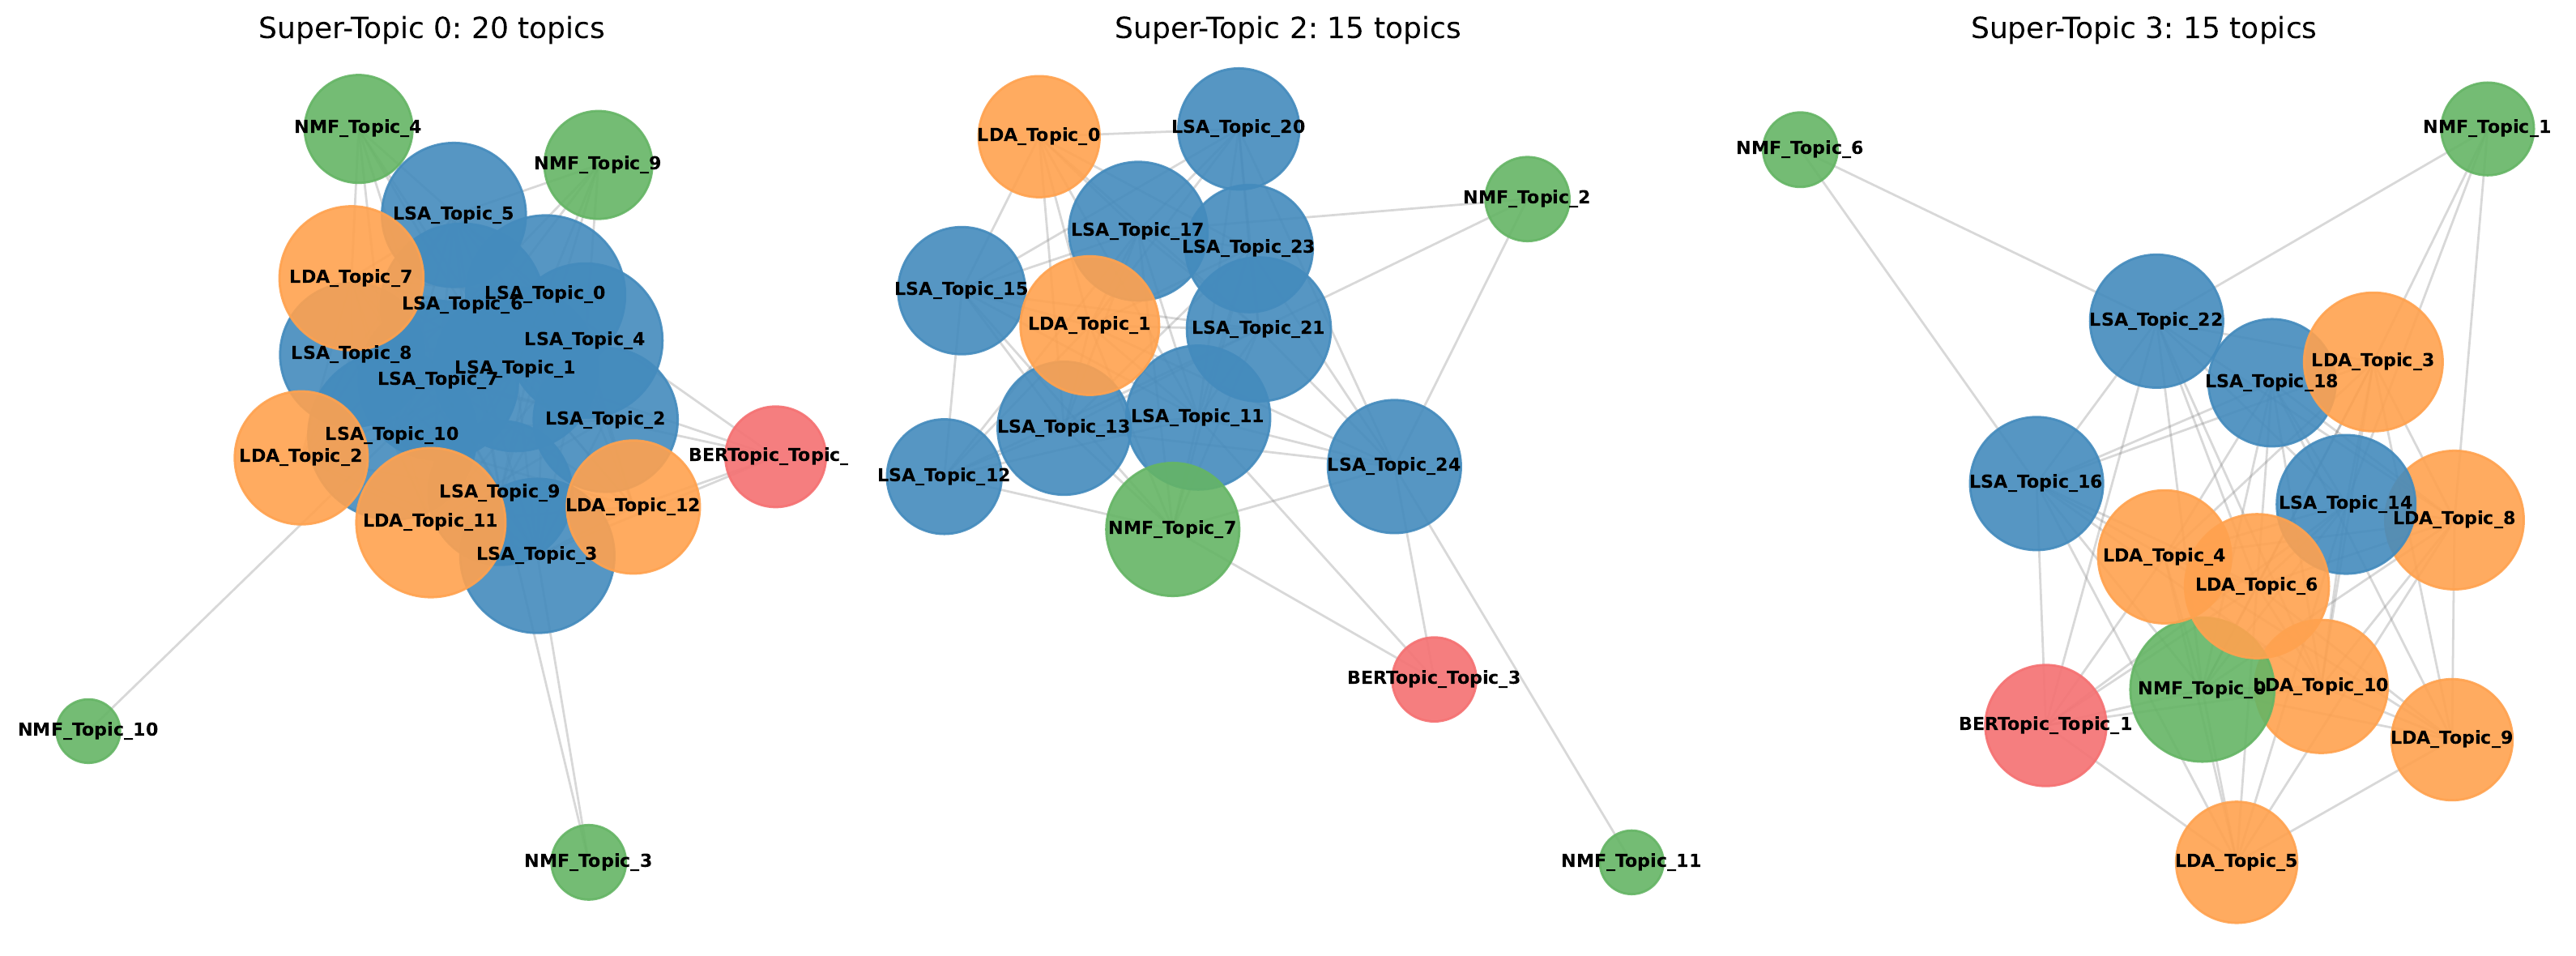

In [15]:
display(Image(filename='../output/figure/super_topics.png'))

In [16]:
super_topics = pd.read_csv('../output/topic_modeling/super_topics.csv')
super_topics

,Super-Topic,LSA,LDA,NMF,BERTopic
0,0,"(1) excellent, good, didactic, explain, subject, teach, content, great, discipline, good, pass, test, know, class, miss","(7) subject, do, always, well, explain, class, material, great, interest, are, talk, take, time, teach, didactic","(4) well, explain, teach, subject, interact, educate, know, master, understand, con, lecture, reasoning, wonderful, quite, efficient","(0) excellent, always, great, good, didactic, excellent, good, doubts, subject, explains, content, about, super, objective"
1,2,"(21) semester, master, well, wonderful, to lack, about, form, to dedicate, difficult, to explain, to administer, to teach, commentary, subject, class","(1) class, leave, semester, work, teach, subject, some, topic, room, content, can, give, class, do, knowledge","(7) domain, subject, content, about, enough, matter, discipline, to teach, Portuguese, to contextualize, to teach, to deal with, form, clear, high","(3) domain, subject, content, quite, day, about, well, passes, knowledge, taught, area, subjects, new, contextualized, excellent"
2,3,"(14) class, teach, always, attentive, classroom, teaching methods, comment, general, student, to be absent, to help, method, test, to explain, willing","(8) subject, form, class, teach, material, because, can, do, student, manner, some, clear, discipline, only, evaluation","(0) class, for, test, content, to do, subject, work, evaluation, semester, little, to leave, form, to be able to, to achieve, to have","(1) content, test, room, evaluation, besides, tests, passed, teaching, lack, little, only, assignments, teaching methods, time, times"


### Exclusive Topics

exclusive_topics = pd.read_csv('../output/topic_modeling/exclusive_topics.csv')
exclusive_topics

## Automatic generative topic labeling

In [18]:
llm_labels = pd.read_csv('../output/llm_labeling/bertopic_llm_labels_en_ver.csv')
llm_labels

,llm_label,keywords
0,Excellent Professor,"['excellent', 'always', 'great', 'well', 'good', 'didactics', 'great', 'good', 'doubts', 'subject', 'explains', 'content', 'about', 'super', 'objective']"
1,Inefficient and Disrespectful Professor With Students,"['content', 'test', 'room', 'evaluation', 'besides', 'tests', 'passed', 'teaching', 'lack', 'little', 'only', 'assignments', 'didactics', 'time', 'times']"
2,Infrastructure Problems and Excessive Classes,"['schedule', 'times', 'reasons', 'some', 'time', 'many', 'too much', 'missed', 'fast', 'bus', 'night', 'work', 'many', 'punctual', 'are']"
3,Subject Mastery is Well Taught,"['mastery', 'subject', 'content', 'quite', 'day', 'about', 'well', 'passes', 'knowledge', 'taught', 'area', 'subjects', 'new', 'contextualized', 'great']"
4,Extremely Disorganized Didactics,"['didactics', 'little', 'excellent', 'uncompromising', 'pretends', 'didactic', 'disorganized', 'terrible', 'points', 'extremely', 'knows', 'quite', 'unrealistic', 'right', 'explosive']"
5,Complicated Semester due to Lack of Communication and Strike,"['disciplines', 'some', 'good', 'difficulties', 'despite', 'strike', 'profitable', 'honestly', 'great', 'subjects', 'pass on', 'after', 'time', 'general', 'unfortunately']"
6,Inadequate Evaluation Method,"['evaluation', 'evaluations', 'could', 'correction', 'clear', 'corrected', 'included', 'discursive', 'method', 'con']"
7,Willing and Attentive Professor,"['always', 'attentive', 'willing', 'solicitous', 'humble', 'hardworking', 'congratulations', 'helpful', 'help', 'well', 'understood', 'engaged', 'disciplined', 'highly', 'arbitrary']"
8,Dissatisfaction with Absence of Information,"['nothing', 'joined', 'recorded', 'declare', 'arrives', 'nor', 'occurred', 'early', 'error', 'social', 'name', 'moment', 'evaluate', 'did', 'grade']"
9,Very Fun and Impeccable Class,"['professional', 'ok', 'impeccable', 'qualified', 'fun', 'xxxxxxxxxxxx', 'regular', 'wonderful', 'wonderful', 'present', 'objective', 'name', 'sir', 'good', 'horrible']"
